# KSWGD on 2D Chessboard Distribution

This notebook applies **Koopman Spectral Wasserstein Gradient Descent (KSWGD)** to transport particles from a uniform distribution over $[-2,2]^2$ to a **chessboard target density**.

## Problem Setup

- **Domain**: $[-2, 2] \times [-2, 2]$
- **Grid**: $4 \times 4$ unit squares (16 cells total, each $1 \times 1$)
- **Target density**: Uniform on 8 "gray" squares (chessboard pattern), zero on 8 "white" squares
- **Initial distribution**: Uniform over the full domain $[-2,2]^2$
- **Goal**: KSWGD transports particles from uniform → chessboard target

## Algorithm (DMPS-style KSWGD)

1. Sample target points $X_{\text{tar}}$ uniformly from the 8 gray squares
2. Build a Gaussian kernel matrix $K$ on $X_{\text{tar}}$
3. Normalize: density estimation $p(x) = \sum_j K(x, x_j)$, then $\tilde{K} = K / (\sqrt{p} \sqrt{p}^T)$
4. Symmetric random-walk normalization → eigendecomposition → spectral weights
5. Initialize particles uniformly in $[-2,2]^2$
6. Iterate KSWGD: $x^{(t+1)} = x^{(t)} - \frac{h}{m} \sum \nabla K \cdot \phi \Lambda^{-1} \phi^T K$
7. Reflect particles at domain boundaries $[-2,2]^2$

In [1]:
# Import libraries and configure GPU/CPU backend
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
import time
import warnings

# Attempt GPU backend
USE_GPU = True
try:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="CUDA path could not be detected")
        import cupy as cp
    GPU_AVAILABLE = True
except Exception:
    cp = None
    GPU_AVAILABLE = False

USE_GPU = bool(USE_GPU and GPU_AVAILABLE)
if USE_GPU:
    from grad_ker1_gpu import grad_ker1 as grad_ker1_gpu
    from K_tar_eval_gpu import K_tar_eval as K_tar_eval_gpu
from grad_ker1 import grad_ker1
from K_tar_eval import K_tar_eval

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["figure.dpi"] = 120

print(f"Backend: {'GPU (CuPy)' if USE_GPU else 'CPU (NumPy)'}")

Backend: GPU (CuPy)


In [2]:
# --- Plot polish settings (visual only) ---
# This cell only controls figure appearance. It does not change sampling, kernels, spectra, or metrics.
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

PAPER_DPI = 160
EXPORT_DPI = 300

plt.rcParams.update({
    'figure.dpi': PAPER_DPI,
    'savefig.dpi': EXPORT_DPI,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'font.family': 'DejaVu Sans',
    'mathtext.fontset': 'dejavusans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 0.9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'image.interpolation': 'nearest',
})

def polish_axes(ax, *, equal=False, grid=False):
    """Apply consistent visual-only axis styling."""
    if equal:
        ax.set_aspect('equal', adjustable='box')
    ax.tick_params(direction='in', length=3, width=0.8)
    if grid:
        ax.grid(True, alpha=0.22, linestyle='--', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color('0.25')
    return ax

def polish_legend(ax, **kwargs):
    """Draw a compact legend only when labelled artists exist."""
    handles, labels = ax.get_legend_handles_labels()
    labels = [label for label in labels if label and not label.startswith('_')]
    if labels:
        defaults = dict(frameon=True, framealpha=0.92, edgecolor='0.85')
        defaults.update(kwargs)
        return ax.legend(**defaults)
    return None

def set_pi_ticks(ax):
    ticks = [0, np.pi, 2 * np.pi]
    labels = ['0', r'$\pi$', r'$2\pi$']
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    return ax


## 1. Define Chessboard Target Distribution

The domain $[-2,2]^2$ is divided into a $4 \times 4$ grid of unit squares. A square at grid index $(i,j)$ is **gray** (has density) if $(i+j) \bmod 2 = 0$, and **white** (zero density) otherwise.

In [3]:
# === Configuration ===
n_target = 2000     # number of target sample points
d = 2               # dimension
GRID_SIZE = 4       # 4x4 grid
SPACING = 4.0 / GRID_SIZE  # = 1.0 per cell
DOMAIN_LO, DOMAIN_HI = -2.0, 2.0

# Identify gray squares: (i+j) % 2 == 0
square_bounds = []
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        if (i + j) % 2 == 0:
            x_lo = i * SPACING + DOMAIN_LO
            y_lo = j * SPACING + DOMAIN_LO
            square_bounds.append([x_lo, y_lo, x_lo + SPACING, y_lo + SPACING])

square_bounds = np.array(square_bounds)
num_gray = len(square_bounds)
print(f"Chessboard: {num_gray} gray squares out of {GRID_SIZE**2}")

# Sample uniformly from gray squares
samples_per_square = n_target // num_gray
remainder = n_target - samples_per_square * num_gray
X_tar_list = []
for idx in range(num_gray):
    ns = samples_per_square + (1 if idx < remainder else 0)
    x_lo, y_lo, x_hi, y_hi = square_bounds[idx]
    pts = np.column_stack([
        np.random.uniform(x_lo, x_hi, ns),
        np.random.uniform(y_lo, y_hi, ns)
    ])
    X_tar_list.append(pts)

X_tar = np.vstack(X_tar_list).astype(np.float64)
np.random.shuffle(X_tar)
n = X_tar.shape[0]
print(f"Generated {n} target points on gray squares")
print(f"X_tar range: x=[{X_tar[:,0].min():.3f}, {X_tar[:,0].max():.3f}], y=[{X_tar[:,1].min():.3f}, {X_tar[:,1].max():.3f}]")

Chessboard: 8 gray squares out of 16
Generated 2000 target points on gray squares
X_tar range: x=[-1.995, 2.000], y=[-1.998, 1.998]


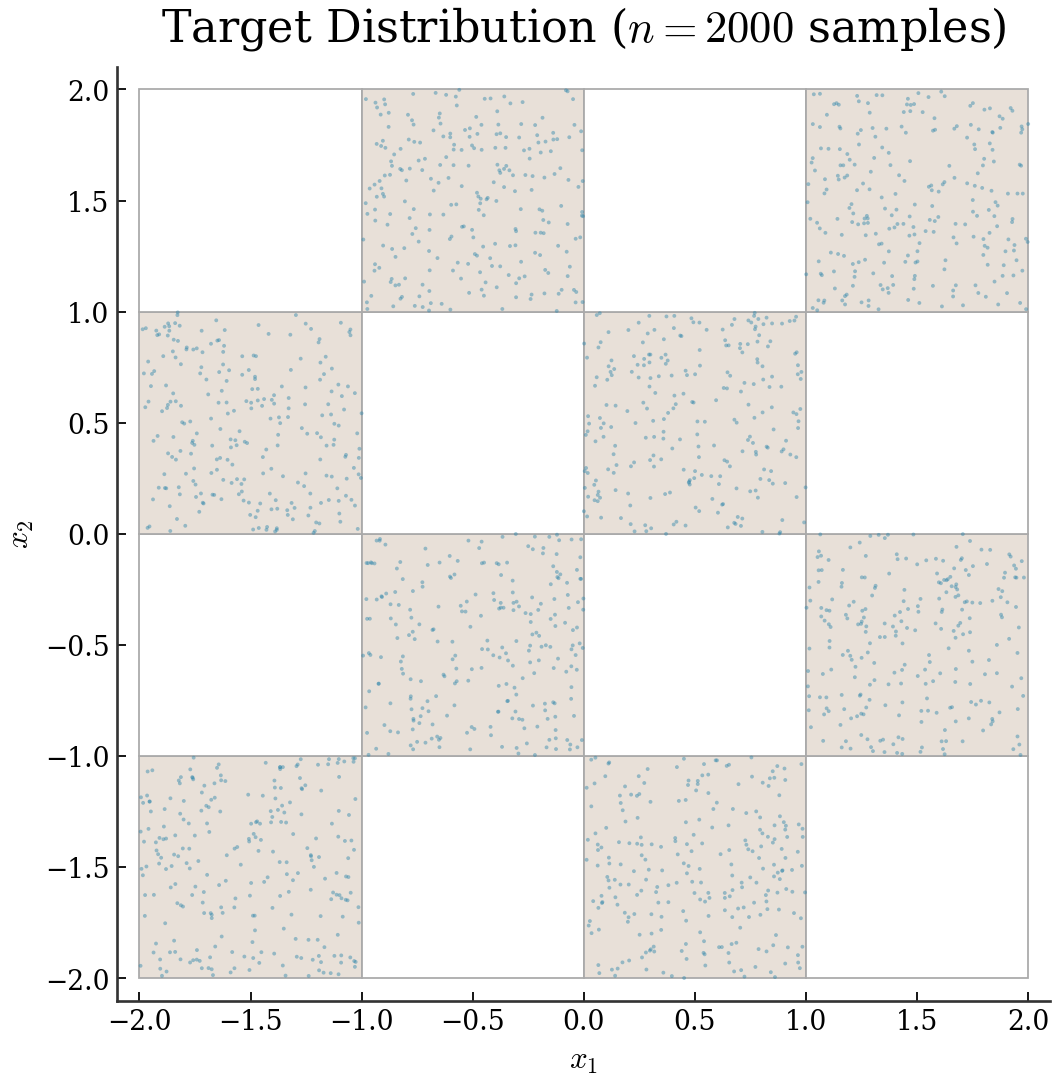

In [4]:
# Visualize target distribution on chessboard
import matplotlib.colors as mcolors

# === Global style settings ===
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
})

# Color palette
GRAY_SQUARE = '#E8E0D8'     # warm light beige-gray
WHITE_SQUARE = '#FFFFFF'
GRID_LINE_COLOR = '#AAAAAA'
TARGET_COLOR = '#2E86AB'     # teal blue
INIT_COLOR = '#E8453C'       # coral red
FINAL_COLOR = '#7B2D8E'      # rich purple
SNAP_CMAP = plt.cm.viridis

def draw_chessboard(ax, grid_size=4, spacing=1.0, domain_lo=-2.0, shadow=True):
    """Draw a polished chessboard background."""
    for i in range(grid_size):
        for j in range(grid_size):
            is_gray = (i + j) % 2 == 0
            color = GRAY_SQUARE if is_gray else WHITE_SQUARE
            rect = plt.Rectangle(
                (i * spacing + domain_lo, j * spacing + domain_lo),
                spacing, spacing,
                facecolor=color, edgecolor=GRID_LINE_COLOR,
                linewidth=0.8, zorder=0
            )
            ax.add_patch(rect)
    ax.set_xlim(domain_lo - 0.1, -domain_lo + 0.1)
    ax.set_ylim(domain_lo - 0.1, -domain_lo + 0.1)
    ax.set_aspect('equal')
    ax.tick_params(direction='in', length=4)

fig, ax = plt.subplots(figsize=(7, 7))
draw_chessboard(ax)
ax.scatter(X_tar[:, 0], X_tar[:, 1], s=3, c=TARGET_COLOR, alpha=0.45,
           edgecolors='none', rasterized=True, zorder=2)
ax.set_title(f'Target Distribution ($n = {n}$ samples)', fontsize=20, pad=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout(pad=1.1)
plt.savefig('figures/chessboard/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Build KSWGD Kernel Operators

Construct the normalized kernel matrix from $X_{\text{tar}}$ and compute the spectral decomposition for KSWGD.

In [5]:
# Compute kernel bandwidth via median heuristic
sq_tar = np.sum(X_tar ** 2, axis=1)
kswgd_dists = pairwise_distances(X_tar, metric='euclidean')
epsilon = np.median(kswgd_dists**2) / (2.0 * np.log(n + 1))
epsilon = float(max(epsilon, 1e-6))
print(f"Kernel bandwidth epsilon = {epsilon:.6f}")
print(f"Distance stats: min={kswgd_dists[kswgd_dists>0].min():.4f}, "
      f"median={np.median(kswgd_dists):.4f}, max={kswgd_dists.max():.4f}")

# Gaussian kernel
data_kernel = np.exp(-kswgd_dists**2 / (2.0 * epsilon))

# DMPS-style density normalization
p_x = np.sqrt(np.sum(data_kernel, axis=1))
data_kernel_norm = data_kernel / (p_x[:, None] * p_x[None, :] + 1e-12)

# Symmetric random-walk normalization
D_y = np.sum(data_kernel_norm, axis=0)
rw_kernel = 0.5 * (data_kernel_norm / (D_y + 1e-12) + data_kernel_norm / (D_y[:, None] + 1e-12))
rw_kernel = np.nan_to_num(rw_kernel)

print(f"Kernel matrix shape: {rw_kernel.shape}")

Kernel bandwidth epsilon = 0.264176
Distance stats: min=0.0013, median=2.0040, max=5.5052
Kernel matrix shape: (2000, 2000)


In [6]:
# Eigendecomposition of normalized kernel
lambda_ns, phi = np.linalg.eigh(rw_kernel)
phi = np.real(phi[:, ::-1])       # descending order
lambda_ns = np.real(lambda_ns[::-1])

# Compute KSWGD spectral weights
tol = 1e-6
reg = 1e-3
lambda_ = 1.0 - lambda_ns          # generator eigenvalues: (1 - lambda_ns) >= 0
inv_lambda = np.zeros_like(lambda_)
inv_lambda[1:] = 1.0 / np.clip(lambda_[1:], 1e-12, None)
inv_lambda *= epsilon

lambda_ns_inv = np.zeros_like(lambda_ns)
mask = lambda_ns >= tol
lambda_ns_inv[mask] = epsilon / (lambda_ns[mask] + reg)
above_tol = int(np.sum(mask))

# Truncated quantities for KSWGD
phi_trunc = phi[:, :above_tol]
lambda_ns_s_ns = (lambda_ns_inv * inv_lambda * lambda_ns_inv)[:above_tol]

# Density and normalization vectors
p_tar = np.sum(data_kernel, axis=0)
sqrt_p = np.sqrt(p_tar + 1e-12)
D_vec = np.sum(data_kernel / sqrt_p[:, None] / sqrt_p[None, :], axis=1)

print(f"Retained eigenvectors: {above_tol} / {n}")
print(f"Leading eigenvalues: {lambda_ns[:10].round(6)}")

Retained eigenvectors: 153 / 2000
Leading eigenvalues: [1.000612 0.950658 0.935316 0.917677 0.834117 0.811905 0.742556 0.613343
 0.325571 0.317477]


## 3. KSWGD Particle Transport

Initialize particles **uniformly** in $[-2,2]^2$ and run KSWGD to transport them toward the gray chessboard squares. Reflecting boundary conditions keep particles inside the domain.

In [7]:
# === KSWGD Parameters ===
m_particles = 500    # number of transported particles
num_iters = 500      # number of iterations
step_size = 1.0     # step size h

# Initialize particles uniformly in [-2, 2]^2
x_init = np.random.uniform(DOMAIN_LO, DOMAIN_HI, (m_particles, d))

print(f"Particles: {m_particles}, Iterations: {num_iters}, Step size: {step_size}")
print(f"Target samples: {n}, Dimension: {d}")

Particles: 500, Iterations: 500, Step size: 1.0
Target samples: 2000, Dimension: 2


In [8]:
# === Run KSWGD ===
from tqdm.auto import trange

def reflect_into_domain_np(x, lo=-2.0, hi=2.0):
    """Reflect particles back into [lo, hi]^d (NumPy)."""
    for dim_idx in range(x.shape[1]):
        while np.any(x[:, dim_idx] < lo) or np.any(x[:, dim_idx] > hi):
            x[:, dim_idx] = np.where(x[:, dim_idx] < lo, 2*lo - x[:, dim_idx], x[:, dim_idx])
            x[:, dim_idx] = np.where(x[:, dim_idx] > hi, 2*hi - x[:, dim_idx], x[:, dim_idx])
        x[:, dim_idx] = np.clip(x[:, dim_idx], lo, hi)
    return x

def reflect_into_domain_gpu(x, lo=-2.0, hi=2.0):
    """Reflect particles back into [lo, hi]^d directly on GPU (CuPy)."""
    for dim_idx in range(x.shape[1]):
        for _ in range(10):  # bounded iterations to avoid infinite loop
            x[:, dim_idx] = cp.where(x[:, dim_idx] < lo, 2*lo - x[:, dim_idx], x[:, dim_idx])
            x[:, dim_idx] = cp.where(x[:, dim_idx] > hi, 2*hi - x[:, dim_idx], x[:, dim_idx])
            if cp.all((x[:, dim_idx] >= lo) & (x[:, dim_idx] <= hi)):
                break
        x[:, dim_idx] = cp.clip(x[:, dim_idx], lo, hi)
    return x

# Choose backend
if USE_GPU:
    grad_fn = grad_ker1_gpu
    K_eval_fn = K_tar_eval_gpu
    xp = cp
    X_tar_dev = cp.asarray(X_tar)
    p_tar_dev = cp.asarray(p_tar)
    sq_tar_dev = cp.asarray(sq_tar)
    D_vec_dev = cp.asarray(D_vec)
    phi_trunc_dev = cp.asarray(phi_trunc)
    lambda_ns_s_ns_dev = cp.asarray(lambda_ns_s_ns)
else:
    grad_fn = grad_ker1
    K_eval_fn = K_tar_eval
    xp = np
    X_tar_dev = X_tar
    p_tar_dev = p_tar
    sq_tar_dev = sq_tar
    D_vec_dev = D_vec
    phi_trunc_dev = phi_trunc
    lambda_ns_s_ns_dev = lambda_ns_s_ns

# Storage for particle history (save snapshots to reduce memory)
snapshot_iters = set([0, num_iters//4, num_iters//2, 3*num_iters//4, num_iters-1])
x_snapshots = {}

# Current particle positions
if USE_GPU:
    x_curr = cp.asarray(x_init.copy(), dtype=cp.float64)
else:
    x_curr = x_init.copy().astype(np.float64)

x_snapshots[0] = x_init.copy()

t_start = time.time()
pbar = trange(num_iters - 1, desc="KSWGD", unit="step")

for t in pbar:
    # Compute kernel gradient and cross-kernel
    grad_matrix = grad_fn(x_curr, X_tar_dev, p_tar_dev, sq_tar_dev, D_vec_dev, epsilon)
    cross_matrix = K_eval_fn(X_tar_dev, x_curr, p_tar_dev, sq_tar_dev, D_vec_dev, epsilon)
    
    # KSWGD update: phi * diag(lambda_ns_s_ns) * phi^T * cross_matrix
    tmp = phi_trunc_dev.T @ cross_matrix
    tmp = lambda_ns_s_ns_dev[:, None] * tmp
    kswgd_push = phi_trunc_dev @ tmp
    
    # Update each dimension
    for dim_idx in range(d):
        sum_term = grad_matrix[:, :, dim_idx] @ kswgd_push
        x_curr[:, dim_idx] = x_curr[:, dim_idx] - (step_size / m_particles) * xp.sum(sum_term, axis=1)
    
    # Reflect into domain (stay on GPU if possible)
    if USE_GPU:
        x_curr = reflect_into_domain_gpu(x_curr, DOMAIN_LO, DOMAIN_HI)
    else:
        x_curr = reflect_into_domain_np(x_curr, DOMAIN_LO, DOMAIN_HI)
    
    # Save snapshot
    if (t + 1) in snapshot_iters:
        if USE_GPU:
            x_snapshots[t + 1] = cp.asnumpy(x_curr).copy()
        else:
            x_snapshots[t + 1] = x_curr.copy()
    
    # Update progress bar with step displacement
    if (t + 1) % 25 == 0 or (t + 1) == num_iters - 1:
        elapsed = time.time() - t_start
        pbar.set_postfix({"elapsed": f"{elapsed:.0f}s"})

# Final particles
if USE_GPU:
    x_final = cp.asnumpy(x_curr)
else:
    x_final = x_curr.copy()

x_snapshots[num_iters - 1] = x_final.copy()
total_time = time.time() - t_start
print(f"\nKSWGD completed in {total_time:.1f}s")

/workspace/kswgd_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KSWGD:   0%|          | 0/499 [00:00<?, ?step/s]

KSWGD:   0%|          | 1/499 [00:01<10:09,  1.22s/step]

KSWGD:   2%|▏         | 12/499 [00:01<00:39, 12.19step/s]

KSWGD:   5%|▍         | 23/499 [00:01<00:19, 24.74step/s]

...

KSWGD:  96%|█████████▌| 479/499 [00:05<00:00, 118.80step/s, elapsed=5s]

KSWGD:  98%|█████████▊| 491/499 [00:05<00:00, 118.89step/s, elapsed=5s]

KSWGD:  98%|█████████▊| 491/499 [00:05<00:00, 118.89step/s, elapsed=5s]

KSWGD: 100%|██████████| 499/499 [00:05<00:00, 91.63step/s, elapsed=5s] 


KSWGD completed in 5.4s


## 4. Visualize Results

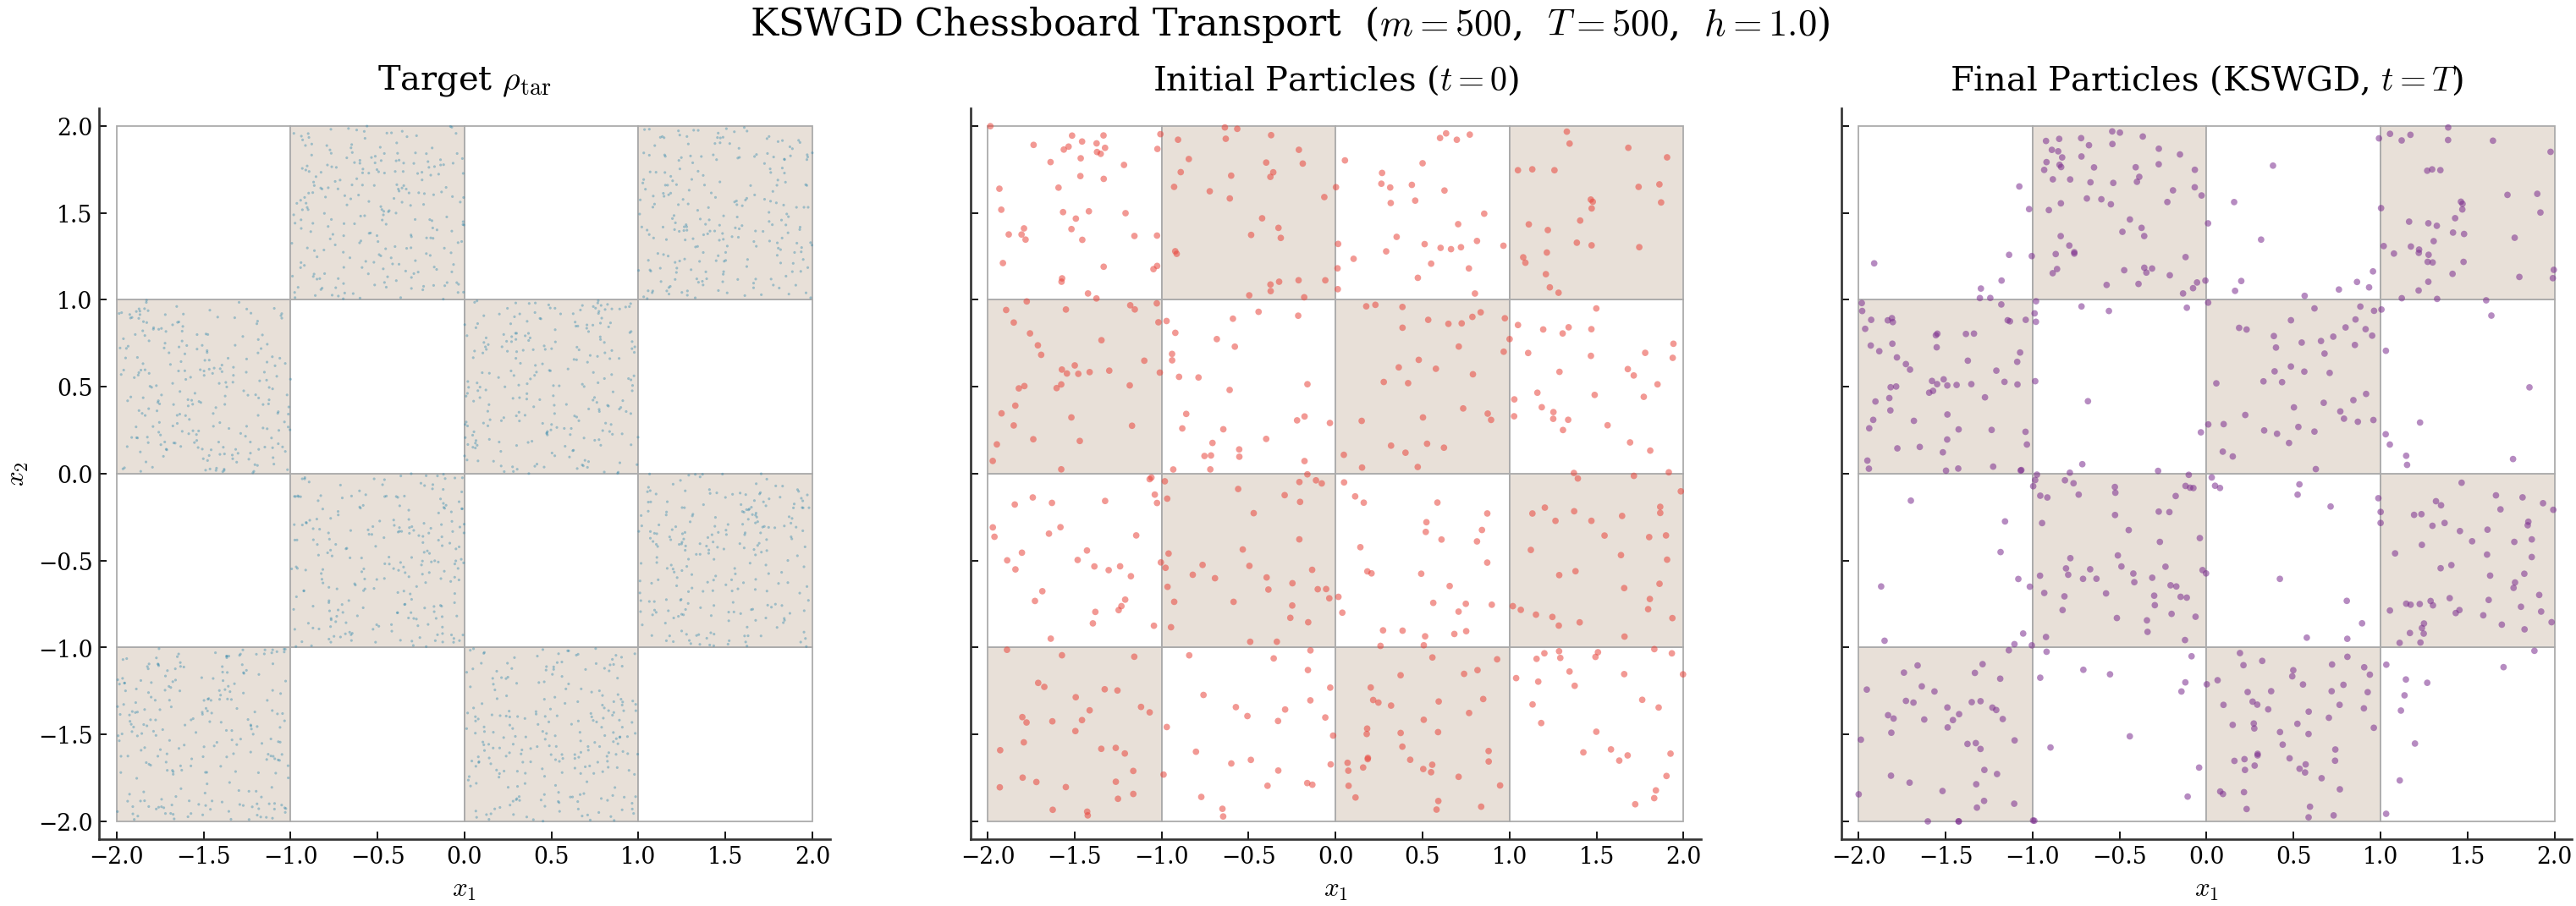


[RESULT] 411/500 particles (82.2%) ended in gray squares


In [9]:
# === Side-by-side: Target, Initial, Final ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

titles = [
    r'Target $\rho_{\mathrm{tar}}$',
    r'Initial Particles ($t = 0$)',
    r'Final Particles (KSWGD, $t = T$)'
]
data_list = [X_tar, x_snapshots[0], x_final]
colors_list = [TARGET_COLOR, INIT_COLOR, FINAL_COLOR]
sizes = [2, 12, 12]
alphas = [0.4, 0.55, 0.55]

for ax_idx in range(3):
    ax = axes[ax_idx]
    draw_chessboard(ax)
    ax.scatter(data_list[ax_idx][:, 0], data_list[ax_idx][:, 1],
               s=sizes[ax_idx], c=colors_list[ax_idx], alpha=alphas[ax_idx],
               edgecolors='none', rasterized=True, zorder=2)
    ax.set_title(titles[ax_idx], fontsize=18, pad=10)
    ax.set_xlabel('$x_1$', fontsize=14)
    if ax_idx == 0:
        ax.set_ylabel('$x_2$', fontsize=14)
    else:
        ax.set_yticklabels([])

fig.suptitle(
    f'KSWGD Chessboard Transport  ($m = {m_particles}$,  $T = {num_iters}$,  $h = {step_size}$)',
    fontsize=20, y=1.01, fontweight='medium'
)
plt.tight_layout(w_pad=1.5)
plt.savefig('figures/chessboard/side_by_side.png', dpi=300, bbox_inches='tight')
plt.show()

# === Quantitative: fraction of final particles in gray squares ===
final_in_gray = np.zeros(m_particles, dtype=bool)
for idx in range(num_gray):
    x_lo, y_lo, x_hi, y_hi = square_bounds[idx]
    inside = ((x_final[:, 0] >= x_lo) & (x_final[:, 0] <= x_hi) &
              (x_final[:, 1] >= y_lo) & (x_final[:, 1] <= y_hi))
    final_in_gray |= inside
pct = 100.0 * np.sum(final_in_gray) / m_particles
print(f"\n[RESULT] {np.sum(final_in_gray)}/{m_particles} particles ({pct:.1f}%) ended in gray squares")

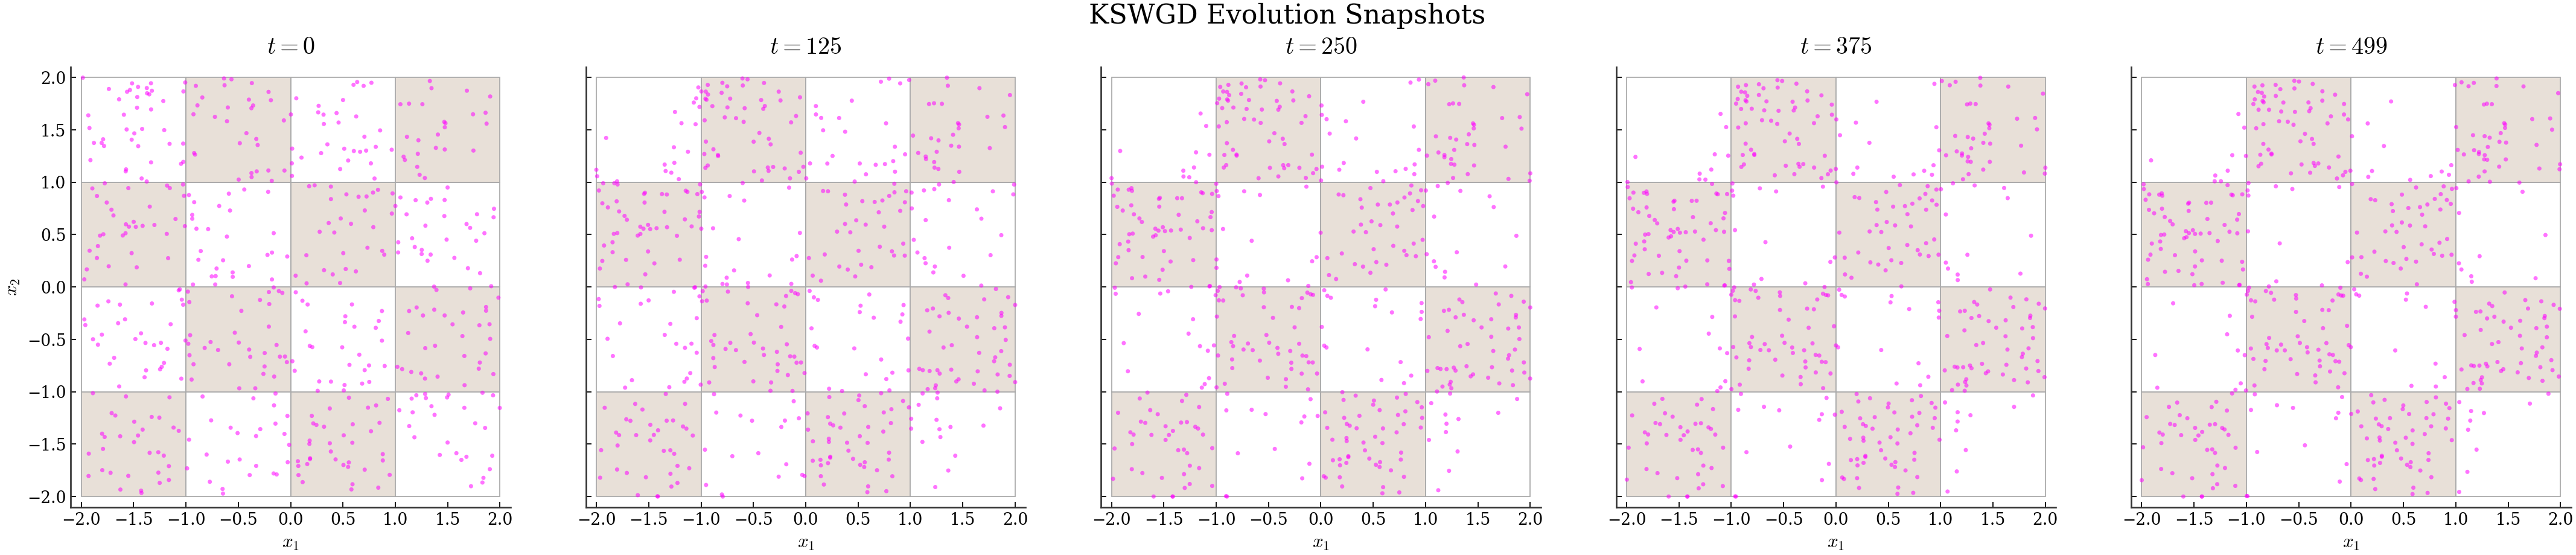

In [10]:
# === Evolution snapshots ===
snap_keys = sorted(x_snapshots.keys())
n_snaps = len(snap_keys)
fig, axes = plt.subplots(1, n_snaps, figsize=(5.5 * n_snaps, 5.5))
if n_snaps == 1:
    axes = [axes]

# Use the same magenta color for all snapshots
snap_color = plt.cm.cool(1.0)

for idx, (ax, key) in enumerate(zip(axes, snap_keys)):
    draw_chessboard(ax)
    ax.scatter(x_snapshots[key][:, 0], x_snapshots[key][:, 1],
               s=10, c=[snap_color], alpha=0.55,
               edgecolors='none', rasterized=True, zorder=2)
    ax.set_title(f'$t = {key}$', fontsize=18, pad=10)
    ax.set_xlabel('$x_1$', fontsize=14)
    if idx == 0:
        ax.set_ylabel('$x_2$', fontsize=14)
    else:
        ax.set_yticklabels([])

fig.suptitle('KSWGD Evolution Snapshots', fontsize=20, y=1.01, fontweight='medium')
plt.tight_layout(w_pad=1.0)
plt.savefig('figures/chessboard/evolution_snapshots.png', dpi=300, bbox_inches='tight')
plt.show()

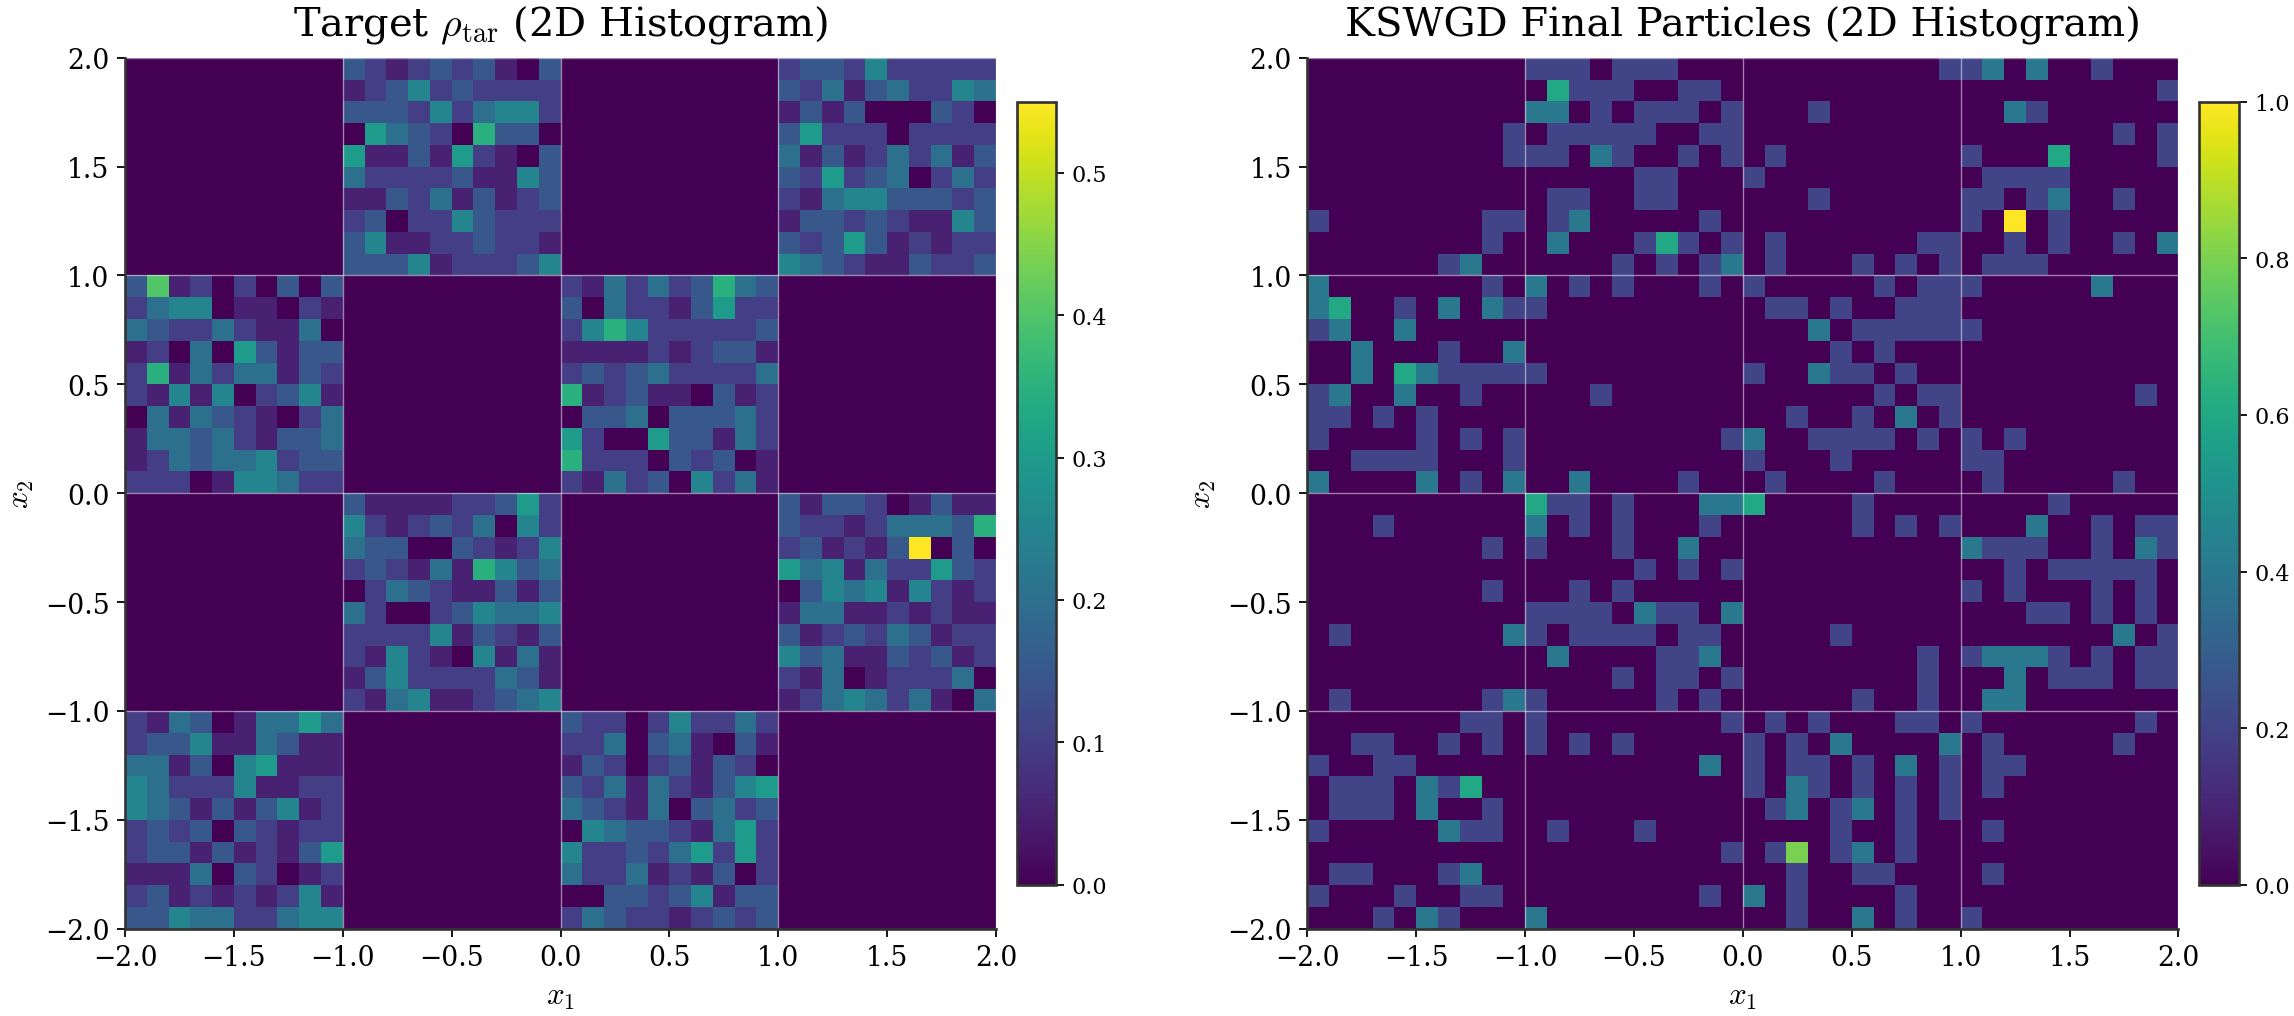

In [11]:
# === 2D Histograms: Target vs KSWGD side-by-side ===
bins = np.linspace(DOMAIN_LO, DOMAIN_HI, 41)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

# --- Target distribution ---
h1 = ax1.hist2d(X_tar[:, 0], X_tar[:, 1], bins=bins, cmap='viridis', density=True)
ax1.set_title(r'Target $\rho_{\mathrm{tar}}$ (2D Histogram)', fontsize=18, pad=10)
ax1.set_aspect('equal')
ax1.set_xlabel('$x_1$', fontsize=14); ax1.set_ylabel('$x_2$', fontsize=14)
# Add grid lines matching chessboard
for k in range(GRID_SIZE + 1):
    coord = DOMAIN_LO + k * SPACING
    ax1.axhline(coord, color='white', linewidth=0.6, alpha=0.5)
    ax1.axvline(coord, color='white', linewidth=0.6, alpha=0.5)
cb1 = plt.colorbar(h1[3], ax=ax1, shrink=0.82, pad=0.02)
cb1.ax.tick_params(labelsize=10)

# --- KSWGD final particles ---
h2 = ax2.hist2d(x_final[:, 0], x_final[:, 1], bins=bins, cmap='viridis', density=True)
ax2.set_title(r'KSWGD Final Particles (2D Histogram)', fontsize=18, pad=10)
ax2.set_aspect('equal')
ax2.set_xlabel('$x_1$', fontsize=14); ax2.set_ylabel('$x_2$', fontsize=14)
for k in range(GRID_SIZE + 1):
    coord = DOMAIN_LO + k * SPACING
    ax2.axhline(coord, color='white', linewidth=0.6, alpha=0.5)
    ax2.axvline(coord, color='white', linewidth=0.6, alpha=0.5)
cb2 = plt.colorbar(h2[3], ax=ax2, shrink=0.82, pad=0.02)
cb2.ax.tick_params(labelsize=10)

plt.tight_layout(w_pad=2.5)
plt.savefig('figures/chessboard/hist2d_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

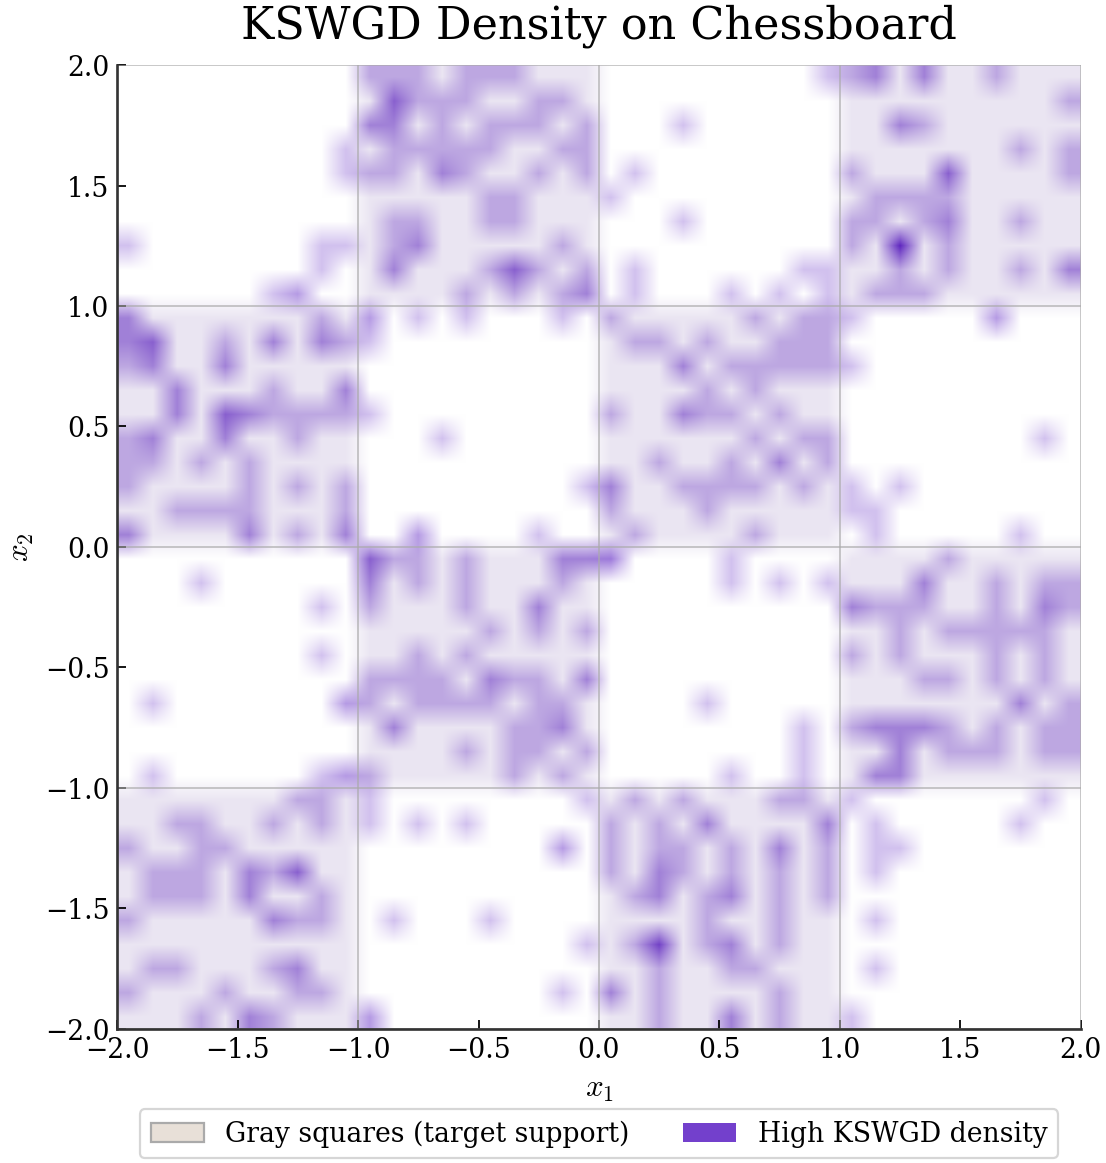

In [12]:
# === 2D Histogram: KSWGD Particles on Chessboard (enhanced) ===
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(8, 7.5))

# Compute 2D histogram for KSWGD final particles
H_fin, xedges, yedges = np.histogram2d(x_final[:, 0], x_final[:, 1], bins=bins, density=True)
H_fin_norm = H_fin / (H_fin.max() + 1e-12)

# Build chessboard mask
chess_mask = np.zeros_like(H_fin_norm)
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])
for ix, xc in enumerate(x_centers):
    for iy, yc in enumerate(y_centers):
        gi = int((xc - DOMAIN_LO) / SPACING)
        gj = int((yc - DOMAIN_LO) / SPACING)
        gi = min(gi, GRID_SIZE - 1)
        gj = min(gj, GRID_SIZE - 1)
        if (gi + gj) % 2 == 0:
            chess_mask[ix, iy] = 1.0

# RGB composition: warm beige base for gray squares, purple-magenta density overlay
rgb = np.ones((H_fin_norm.shape[0], H_fin_norm.shape[1], 3))

# Gray squares: warm beige tint
rgb[:, :, 0] -= chess_mask * 0.08   # R
rgb[:, :, 1] -= chess_mask * 0.10   # G
rgb[:, :, 2] -= chess_mask * 0.05   # B

# Density overlay: deep purple gradient
intensity = H_fin_norm ** 0.7  # gamma correction for better contrast
rgb[:, :, 0] -= intensity * 0.55
rgb[:, :, 1] -= intensity * 0.75
rgb[:, :, 2] -= intensity * 0.20
rgb = np.clip(rgb, 0, 1)

rgb_display = np.transpose(rgb, (1, 0, 2))[::-1]
ax.imshow(rgb_display, extent=[DOMAIN_LO, DOMAIN_HI, DOMAIN_LO, DOMAIN_HI],
          aspect='equal', interpolation='bilinear')

# Grid lines
for k in range(GRID_SIZE + 1):
    coord = DOMAIN_LO + k * SPACING
    ax.axhline(coord, color=GRID_LINE_COLOR, linewidth=0.8, alpha=0.7)
    ax.axvline(coord, color=GRID_LINE_COLOR, linewidth=0.8, alpha=0.7)

ax.set_title('KSWGD Density on Chessboard', fontsize=20, pad=12)
ax.set_xlabel('$x_1$', fontsize=14)
ax.set_ylabel('$x_2$', fontsize=14)
ax.tick_params(direction='in', length=4)

# Legend
legend_elements = [
    Patch(facecolor=GRAY_SQUARE, edgecolor=GRID_LINE_COLOR, label='Gray squares (target support)'),
    Patch(facecolor=(0.45, 0.25, 0.80), label='High KSWGD density'),
]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.07), ncol=2, frameon=True,
          edgecolor='#CCCCCC', fancybox=True)
plt.tight_layout(pad=1.1)
plt.savefig('figures/chessboard/kswgd_density_chessboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# === Per-square occupancy analysis ===
print("Per-square particle counts (final):")
print(f"{'Square':>10} | {'x range':>16} | {'y range':>16} | {'Count':>6} | {'Expected':>8}")
print("-" * 70)

expected_per_square = m_particles / num_gray
for idx in range(num_gray):
    x_lo, y_lo, x_hi, y_hi = square_bounds[idx]
    inside = ((x_final[:, 0] >= x_lo) & (x_final[:, 0] <= x_hi) &
              (x_final[:, 1] >= y_lo) & (x_final[:, 1] <= y_hi))
    count = np.sum(inside)
    print(f"  Gray {idx:2d}  | [{x_lo:5.1f}, {x_hi:5.1f}]   | [{y_lo:5.1f}, {y_hi:5.1f}]   | {count:5d}  | {expected_per_square:7.1f}")

# Count particles in white squares
white_count = m_particles - np.sum(final_in_gray)
print(f"\nParticles in white squares: {white_count} ({100*white_count/m_particles:.1f}%)")
print(f"Particles in gray squares:  {np.sum(final_in_gray)} ({pct:.1f}%)")

Per-square particle counts (final):
    Square |          x range |          y range |  Count | Expected
----------------------------------------------------------------------
  Gray  0  | [ -2.0,  -1.0]   | [ -2.0,  -1.0]   |    42  |    62.5
  Gray  1  | [ -2.0,  -1.0]   | [  0.0,   1.0]   |    61  |    62.5
  Gray  2  | [ -1.0,   0.0]   | [ -1.0,   0.0]   |    54  |    62.5
  Gray  3  | [ -1.0,   0.0]   | [  1.0,   2.0]   |    60  |    62.5
  Gray  4  | [  0.0,   1.0]   | [ -2.0,  -1.0]   |    54  |    62.5
  Gray  5  | [  0.0,   1.0]   | [  0.0,   1.0]   |    44  |    62.5
  Gray  6  | [  1.0,   2.0]   | [ -1.0,   0.0]   |    54  |    62.5
  Gray  7  | [  1.0,   2.0]   | [  1.0,   2.0]   |    42  |    62.5

Particles in white squares: 89 (17.8%)
Particles in gray squares:  411 (82.2%)


## 5. Eigenvalue Spectrum Analysis

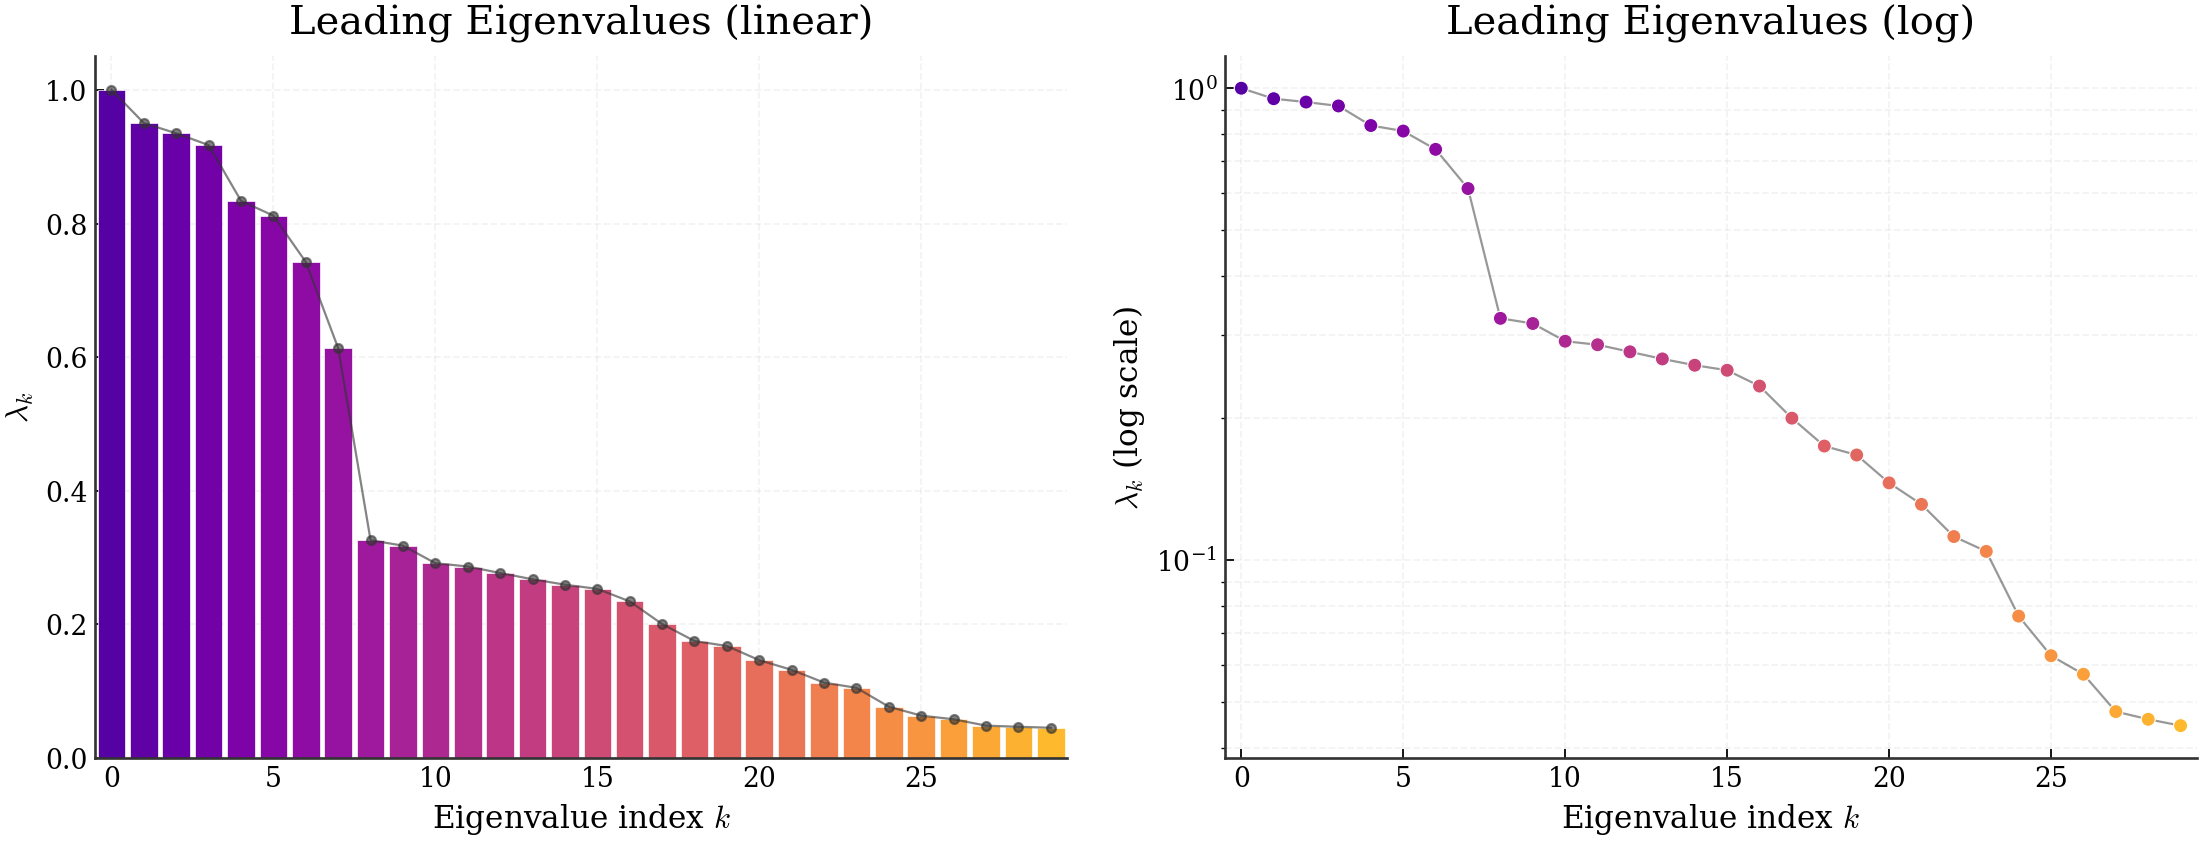

First 10 eigenvalues: [1.000612 0.950658 0.935316 0.917677 0.834117 0.811905 0.742556 0.613343
 0.325571 0.317477]


In [14]:
# Plot eigenvalue decay
n_show_eigs = min(30, len(lambda_ns))
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Color gradient for eigenvalue markers
eig_colors = plt.cm.plasma(np.linspace(0.15, 0.85, n_show_eigs))

# --- Linear scale ---
axes[0].bar(range(n_show_eigs), lambda_ns[:n_show_eigs],
            color=eig_colors, edgecolor='white', linewidth=0.3, width=0.85, zorder=2)
axes[0].plot(range(n_show_eigs), lambda_ns[:n_show_eigs], 'o-',
             color='#333333', markersize=4, linewidth=1, alpha=0.6, zorder=3)
axes[0].set_xlabel('Eigenvalue index $k$', fontsize=14)
axes[0].set_ylabel(r'$\lambda_k$', fontsize=14)
axes[0].set_title('Leading Eigenvalues (linear)', fontsize=18, pad=10)
axes[0].grid(True, alpha=0.15, linestyle='--')
axes[0].set_xlim(-0.5, n_show_eigs - 0.5)

# --- Log scale ---
positive_eigs = lambda_ns[lambda_ns > 0]
n_pos = min(n_show_eigs, len(positive_eigs))
eig_colors_log = plt.cm.plasma(np.linspace(0.15, 0.85, n_pos))
axes[1].semilogy(range(n_pos), positive_eigs[:n_pos], 'o-',
                 color='#333333', markersize=3, linewidth=1, alpha=0.5, zorder=2)
axes[1].scatter(range(n_pos), positive_eigs[:n_pos], c=eig_colors_log,
                s=40, edgecolors='white', linewidths=0.5, zorder=3)
axes[1].set_xlabel('Eigenvalue index $k$', fontsize=14)
axes[1].set_ylabel(r'$\lambda_k$ (log scale)', fontsize=14)
axes[1].set_title('Leading Eigenvalues (log)', fontsize=18, pad=10)
axes[1].grid(True, alpha=0.15, linestyle='--', which='both')
axes[1].set_xlim(-0.5, n_pos - 0.5)

for ax in axes:
    ax.tick_params(direction='in', length=4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(w_pad=2.0)
plt.savefig('figures/chessboard/eigenvalue_spectrum.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/chessboard/eigenvalue_spectrum.pdf', bbox_inches='tight')
plt.show()

print(f"First 10 eigenvalues: {lambda_ns[:10].round(6)}")

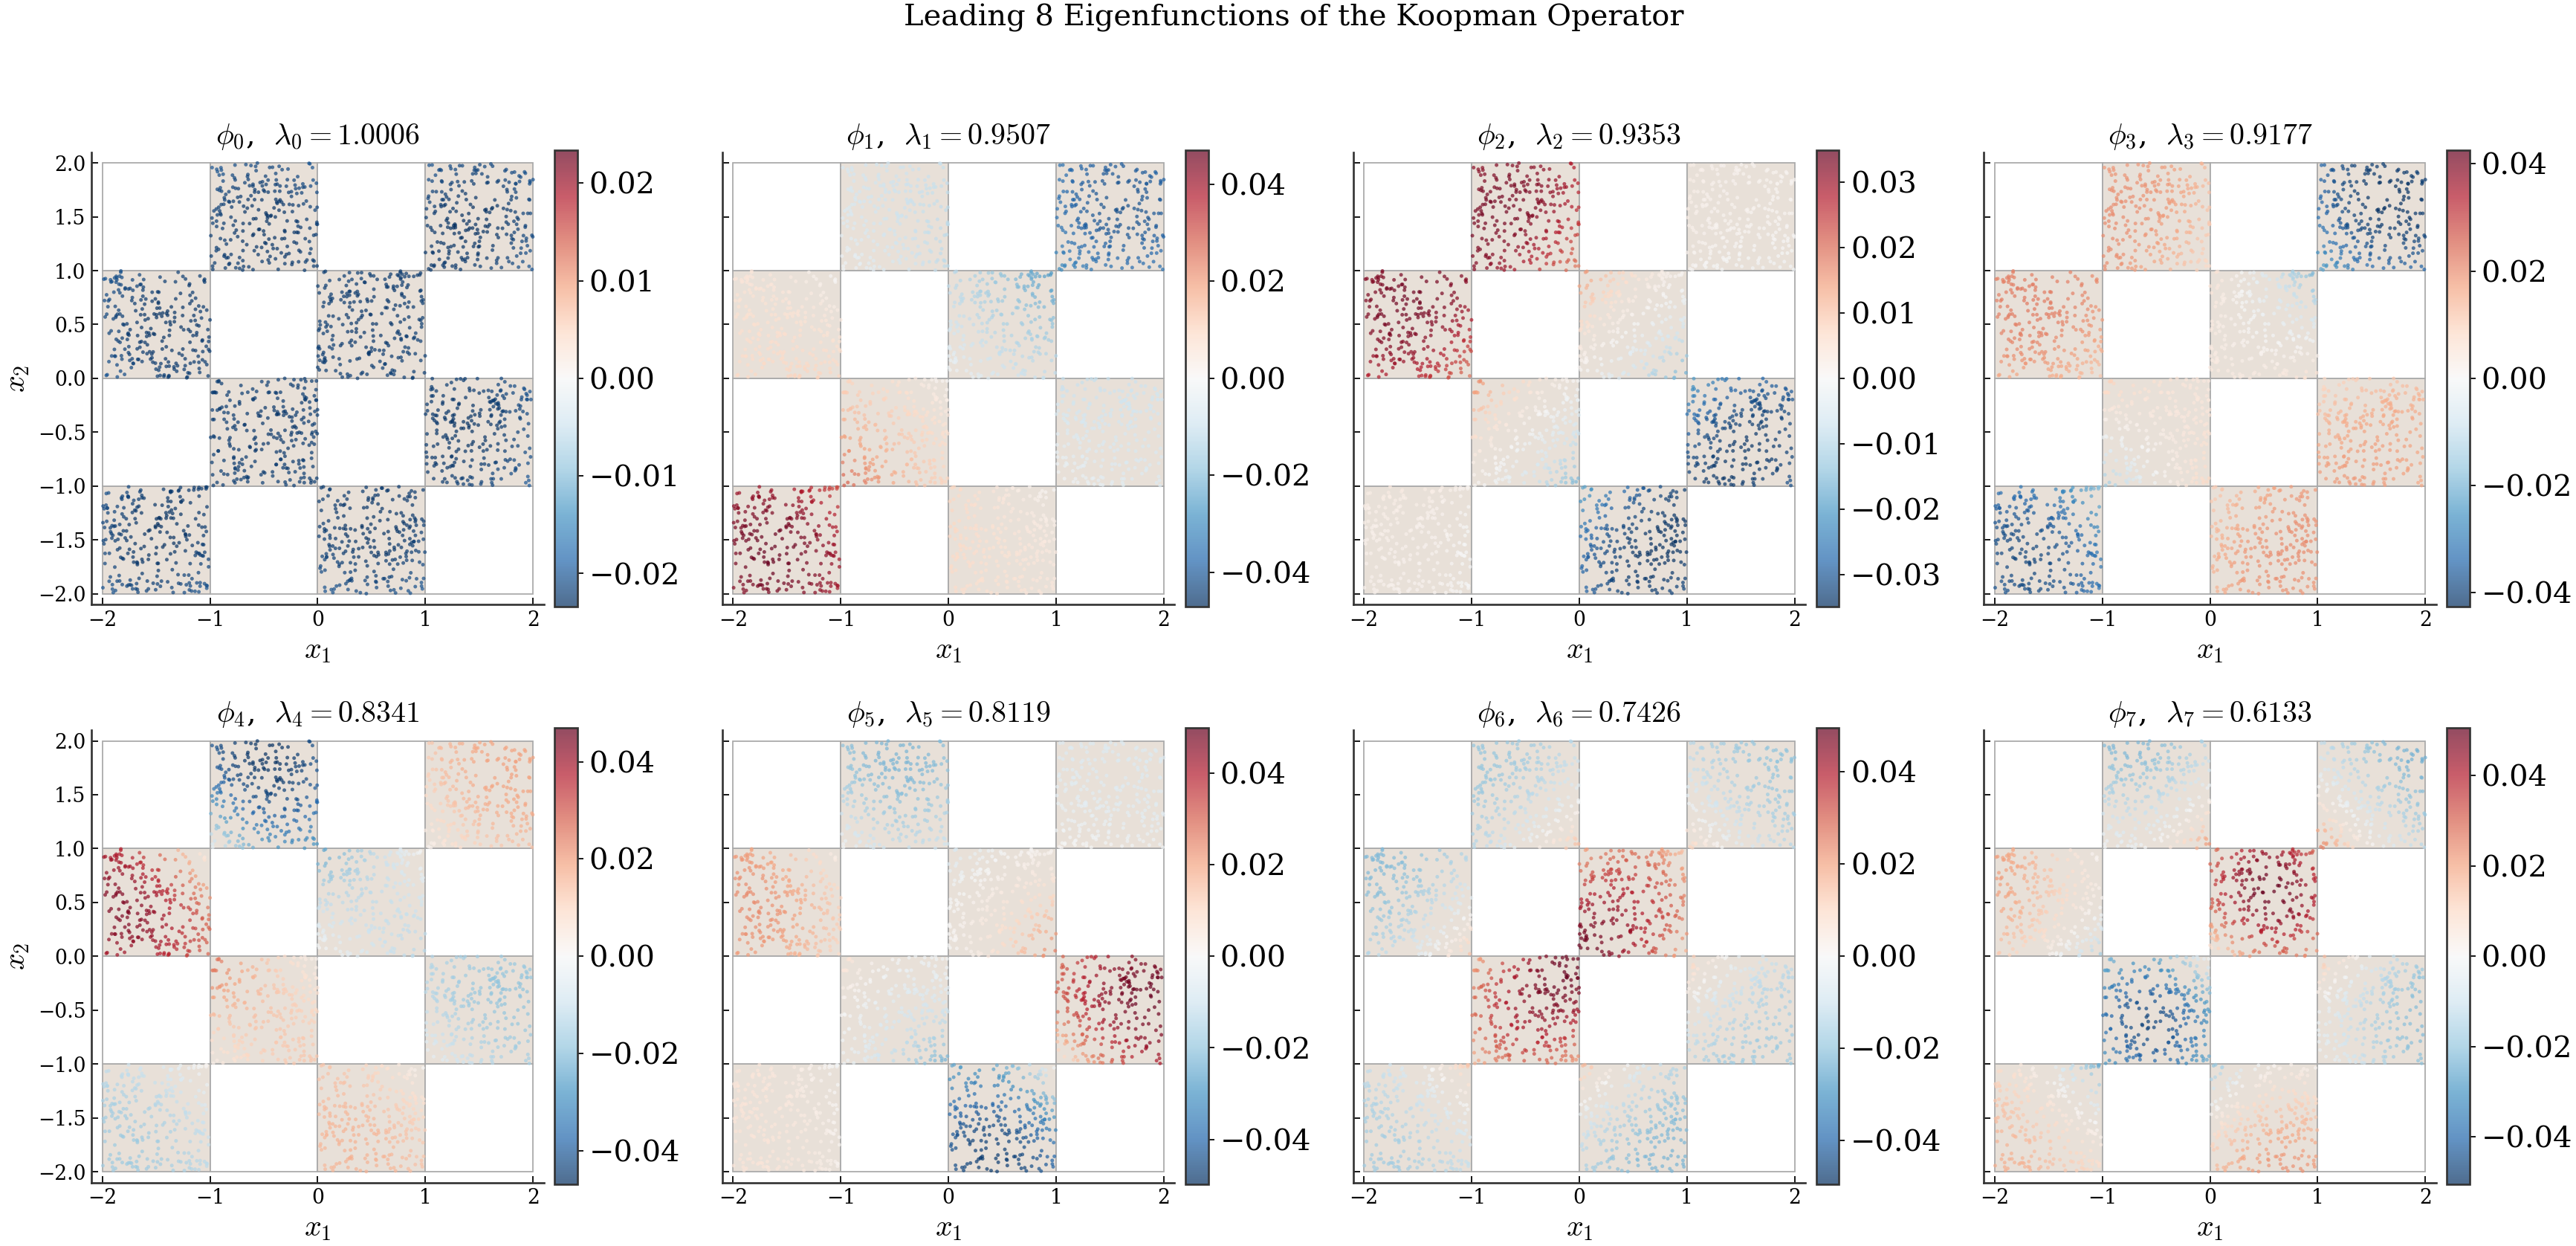

In [15]:
# === Visualize the 8 leading eigenfunctions on the chessboard domain ===
n_eig_show = 8
fig, axes = plt.subplots(2, 4, figsize=(22, 11))

for k in range(n_eig_show):
    ax = axes[k // 4, k % 4]
    draw_chessboard(ax)
    
    # phi[:, k] contains eigenfunction values at X_tar points
    eig_vals = phi[:, k]
    
    # Symmetric color limits for diverging colormap
    vmax = np.max(np.abs(eig_vals))
    
    sc = ax.scatter(X_tar[:, 0], X_tar[:, 1], s=5, c=eig_vals,
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                    alpha=0.7, edgecolors='none', rasterized=True, zorder=2)
    
    ax.set_title(rf'$\phi_{{{k}}}$,  $\lambda_{{{k}}} = {lambda_ns[k]:.4f}$',
                 fontsize=18, pad=5)
    ax.set_xlabel('$x_1$', fontsize=18)
    if k % 4 == 0:
        ax.set_ylabel('$x_2$', fontsize=18)
    else:
        ax.set_yticklabels([])
    
    cb = plt.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
    cb.ax.tick_params(labelsize=18)

fig.suptitle('Leading 8 Eigenfunctions of the Koopman Operator',
             fontsize=18, y=0.965, fontweight='medium')
plt.tight_layout(w_pad=1.5, h_pad=1.4, rect=[0, 0, 1, 0.94])
plt.savefig('figures/chessboard/leading_eigenfunctions.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/chessboard/leading_eigenfunctions.pdf', bbox_inches='tight')
plt.show()

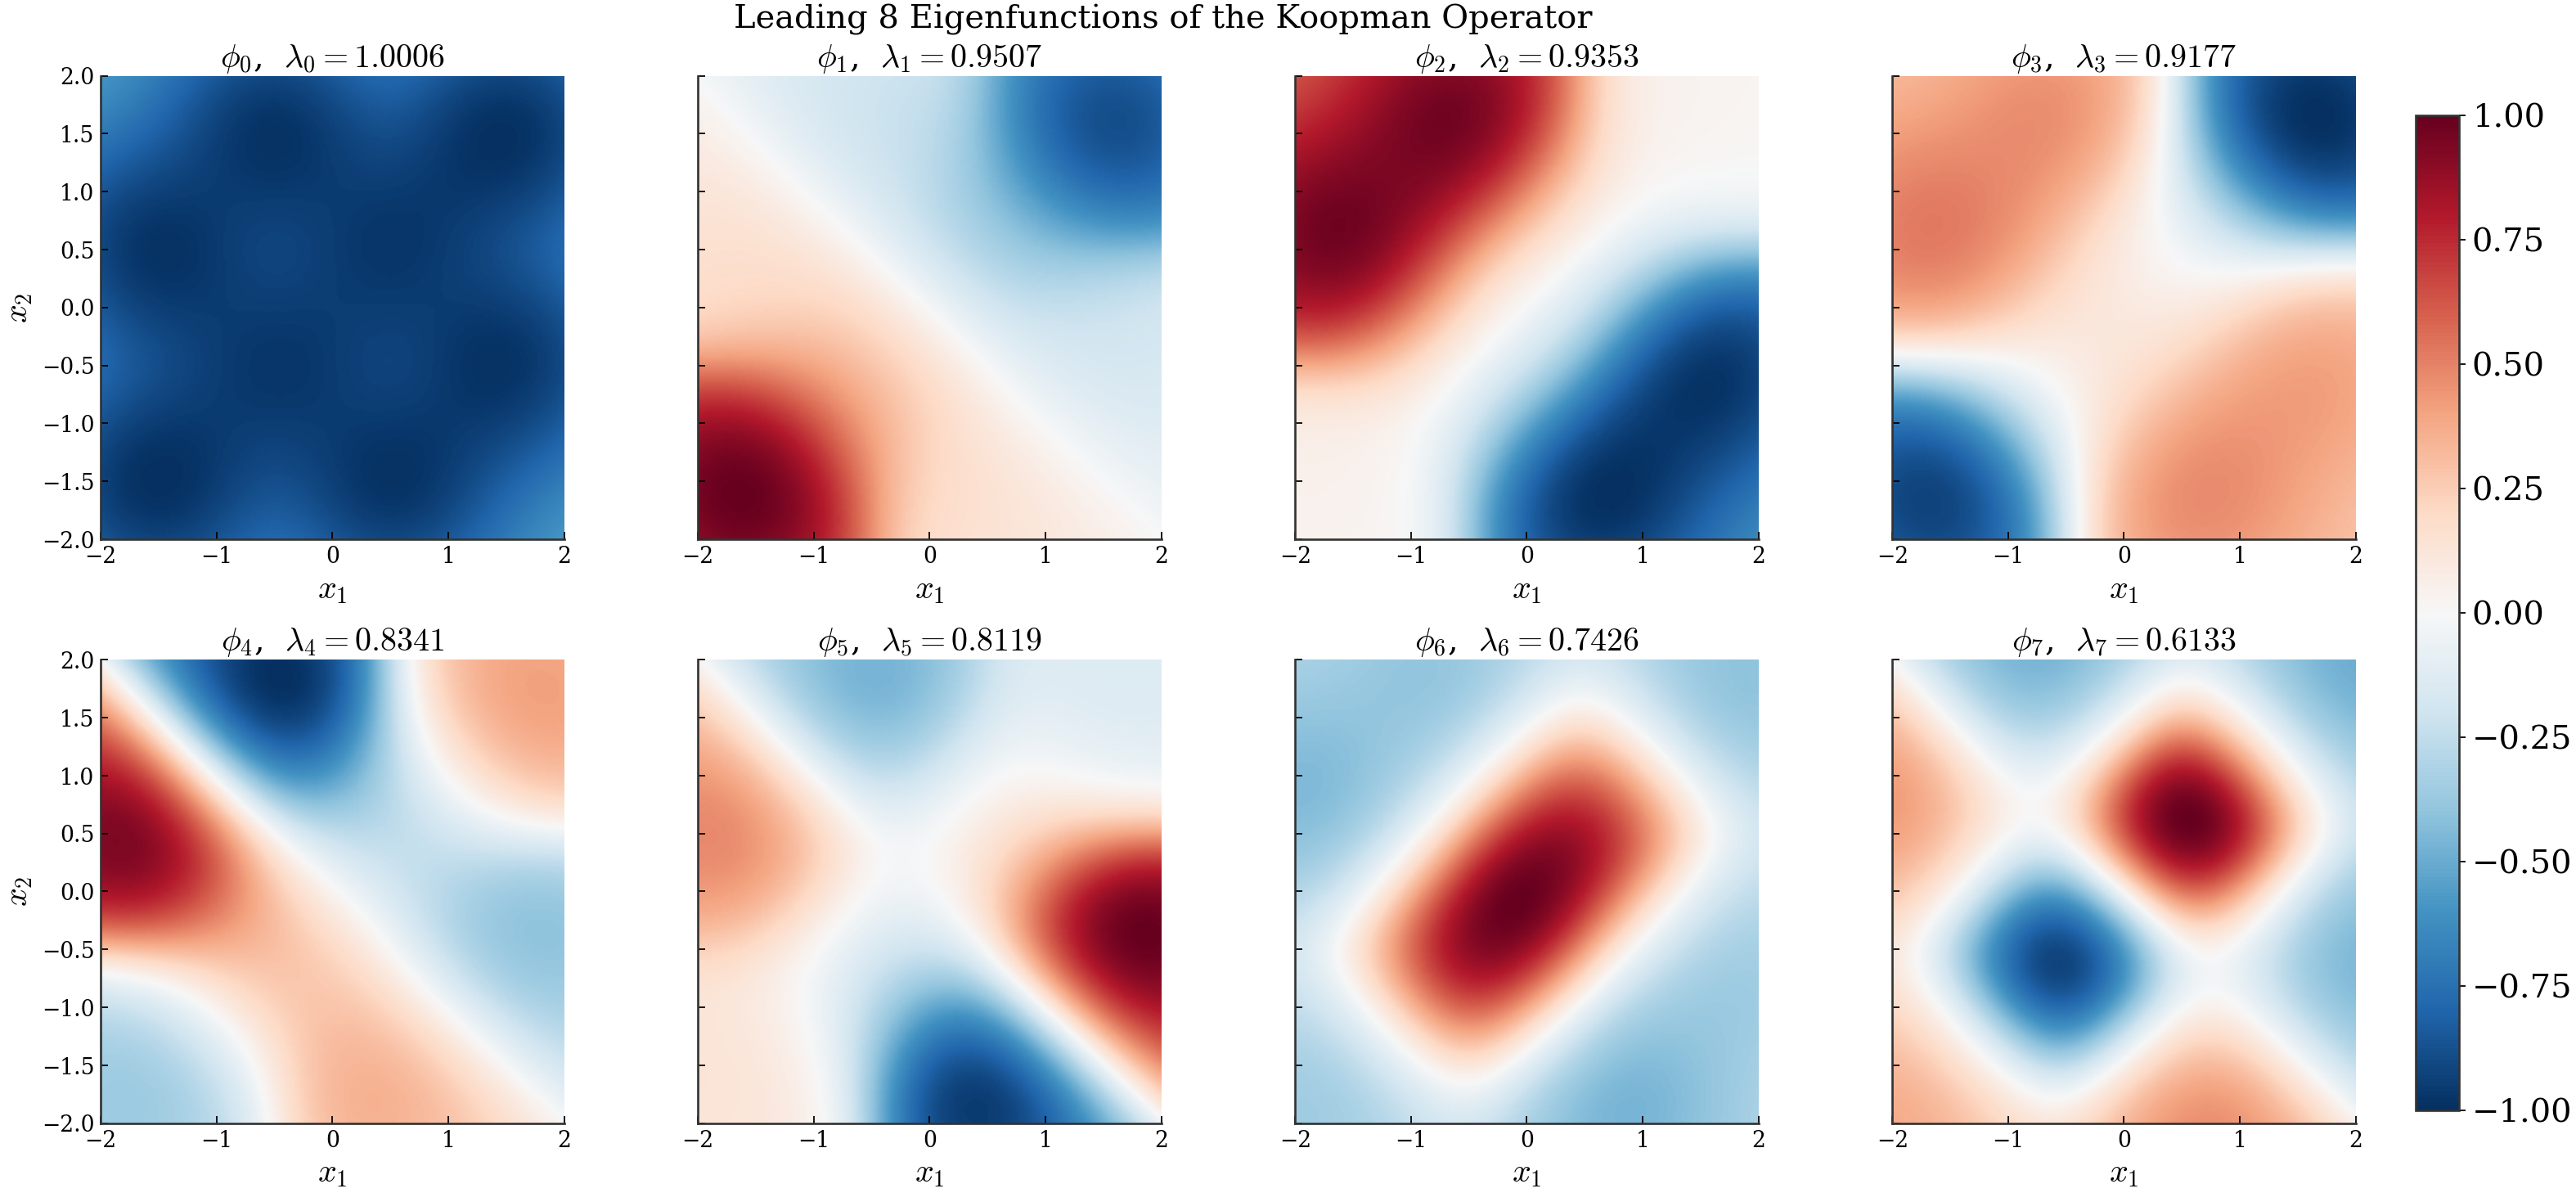

Grid: 200x200 = 40000 evaluation points


In [16]:
# === Eigenfunctions via Nyström extension on full 2D grid ===
# Nyström extension: extrapolate discrete eigenvectors from X_tar to the entire domain
# phi_k(x) = (1/lambda_k) * sum_j K_norm(x, x_j) * phi_k(x_j)
n_grid = 200  # 200x200 grid points
x1_grid = np.linspace(DOMAIN_LO, DOMAIN_HI, n_grid)
x2_grid = np.linspace(DOMAIN_LO, DOMAIN_HI, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])  # (n_grid^2, 2)

# Compute cross-kernel between grid points and X_tar
sq_grid = np.sum(X_grid ** 2, axis=1)
K_cross_grid = np.exp(-(sq_grid[:, None] + sq_tar[None, :] - 2 * X_grid @ X_tar.T) / (2 * epsilon))

# Density at grid points and density normalization
p_grid = np.sum(K_cross_grid, axis=1)
M_grid = K_cross_grid / np.sqrt(p_grid)[:, None] / np.sqrt(p_tar)[None, :]

# Using the same normalization as rw_kernel (average of two normalizations)
D_grid = np.sum(M_grid, axis=1)
M_norm1 = M_grid / D_grid[:, None]        # row-normalized
M_norm2 = M_grid / D_vec[None, :]         # column-normalized by D_vec from training
M_nystrom = 0.5 * (M_norm1 + M_norm2)

n_eig_show = 8
phi_grid = np.zeros((X_grid.shape[0], n_eig_show))
for k in range(n_eig_show):
    phi_grid[:, k] = M_nystrom @ phi[:, k] / (lambda_ns[k] + 1e-12)

# Normalize each eigenfunction to [-1, 1]
phi_grid_norm = np.zeros_like(phi_grid)
for k in range(n_eig_show):
    max_abs = np.max(np.abs(phi_grid[:, k]))
    phi_grid_norm[:, k] = phi_grid[:, k] / (max_abs + 1e-12)

# Plot 2x4 with shared normalized colorbar
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for k in range(n_eig_show):
    ax = axes[k // 4, k % 4]
    vals = phi_grid_norm[:, k].reshape(n_grid, n_grid)
    
    im = ax.pcolormesh(X1, X2, vals, cmap='RdBu_r', vmin=-1, vmax=1,
                       shading='gouraud', rasterized=True)
    
    ax.set_title(rf'$\phi_{{{k}}}$,  $\lambda_{{{k}}} = {lambda_ns[k]:.4f}$',
                 fontsize=18, pad=5)
    ax.set_xlim(DOMAIN_LO, DOMAIN_HI)
    ax.set_ylim(DOMAIN_LO, DOMAIN_HI)
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$', fontsize=18)
    if k % 4 == 0:
        ax.set_ylabel('$x_2$', fontsize=18)
    else:
        ax.set_yticklabels([])
    ax.tick_params(direction='in', length=4)

# Single shared colorbar
fig.subplots_adjust(right=0.92, top=0.91, hspace=0.26)
cbar_ax = fig.add_axes([0.935, 0.12, 0.015, 0.76])
cb = fig.colorbar(im, cax=cbar_ax)
# cb.set_label('Normalized eigenfunction value', fontsize=16)
cb.ax.tick_params(labelsize=18)

fig.suptitle('Leading 8 Eigenfunctions of the Koopman Operator',
             fontsize=18, y=0.965, fontweight='medium')
plt.savefig('figures/chessboard/leading_eigenfunctions_2.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/chessboard/leading_eigenfunctions_2.pdf', bbox_inches='tight')
plt.show()

print(f"Grid: {n_grid}x{n_grid} = {n_grid**2} evaluation points")